In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

In [2]:
image = cv2.imread('img_task2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

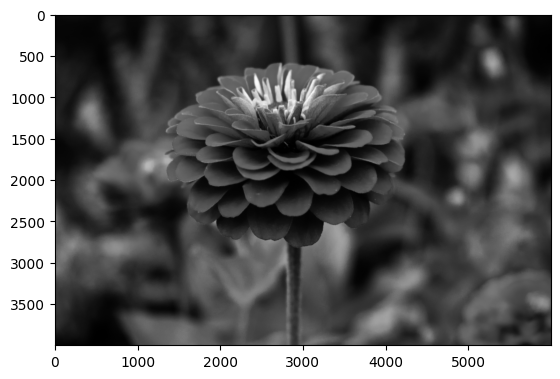

In [3]:
plt.imshow(image_gray, cmap="gray")

# Зашумить изображение при помощи шума гаусса, постоянного шума.

In [4]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 150,  56,   0],
       [ 86,   0, 238, ...,   0,   0,  36],
       [ 39, 106,   0, ...,   0, 194,   0],
       ...,
       [  0,   0,  36, ...,   0,  35, 139],
       [  0,   0,   0, ...,   0, 106,   0],
       [102,   0,   0, ...,   0,  67,   0]],
      shape=(4000, 6000), dtype=uint8)

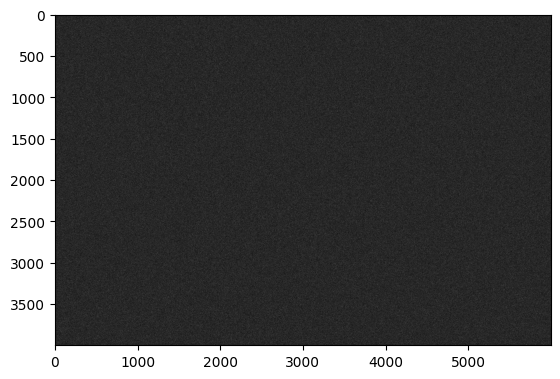

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [7]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [8]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

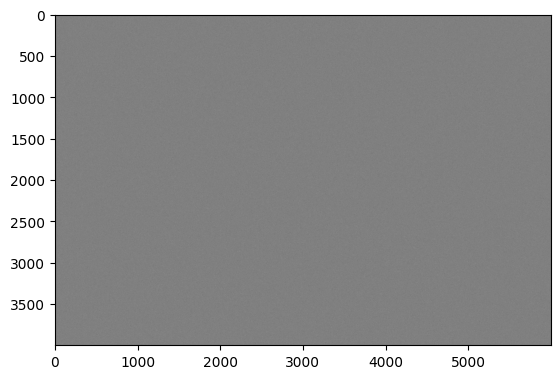

In [9]:
plt.imshow(bg_image, cmap="gray")

In [10]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

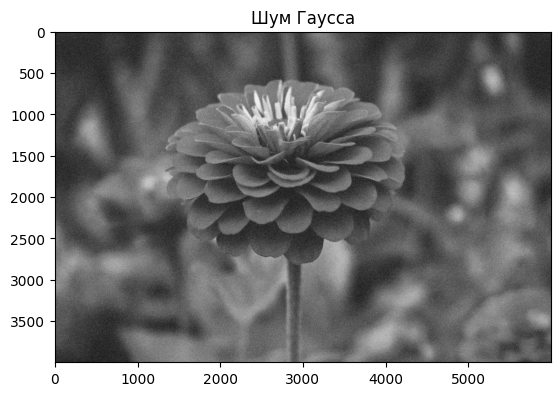

In [11]:
plt.title('Шум Гаусса')
plt.imshow(image_noise_gauss, cmap="gray")

In [12]:
import copy

image_noise_sp = copy.deepcopy(image_gray)

image_noise_sp[zeros_pixel] = 0
image_noise_sp[ones_pixel] = 255

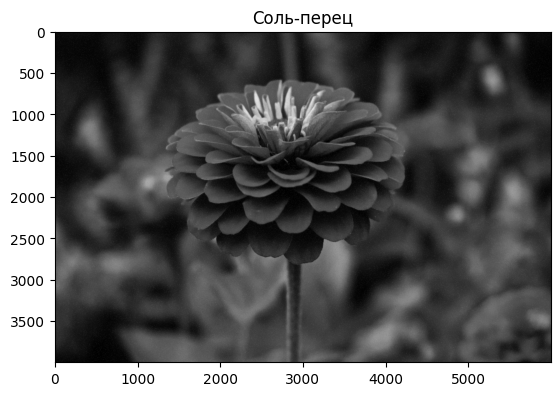

In [13]:
plt.title('Соль-перец')
plt.imshow(image_noise_sp, cmap="gray")

# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [14]:
def mse_ssim(original, processed, index = ''):
    mse = mean_squared_error(original, processed)
    ssim = structural_similarity(original, processed)
    print(f'{index}: MSE = {mse} ; SSIM = {ssim}')
    

Медианный фильтр

k = 3: MSE = 844.7858265416667 ; SSIM = 0.15413137642687688
k = 5: MSE = 334.3239222916667 ; SSIM = 0.3647970954604762
k = 7: MSE = 189.859616875 ; SSIM = 0.5418175196115137


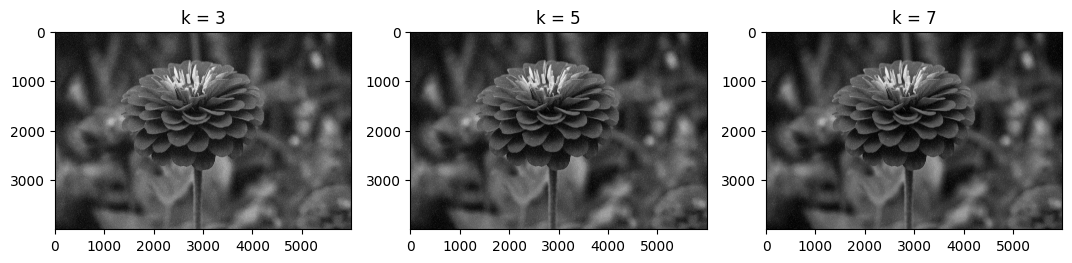

In [37]:
# Шум Гауcса
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.medianBlur(image_noise_gauss, k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()


k = 3: MSE = 8.1651705 ; SSIM = 0.9069627928571827
k = 5: MSE = 12.697626541666667 ; SSIM = 0.8490369470315852
k = 7: MSE = 12.821849666666667 ; SSIM = 0.8469395842589199


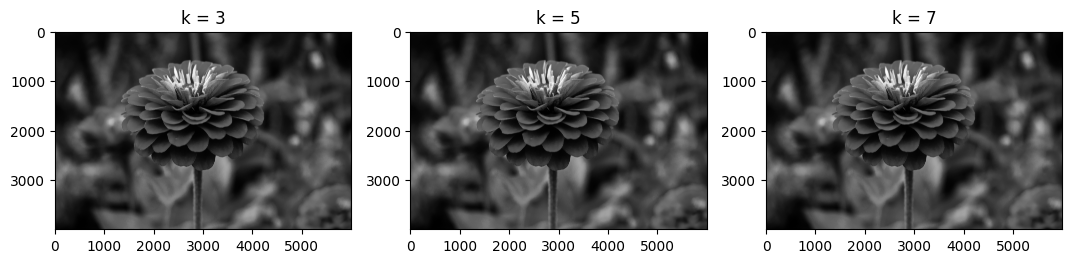

In [38]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.medianBlur(image_noise_sp, k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

Фильтр Гауса

k = 7: MSE = 1628.2672788333334 ; SSIM = 0.34623394774364064
k = 9: MSE = 1592.3502415 ; SSIM = 0.41875043627302727
k = 11: MSE = 1570.0411787083333 ; SSIM = 0.47905719080143033


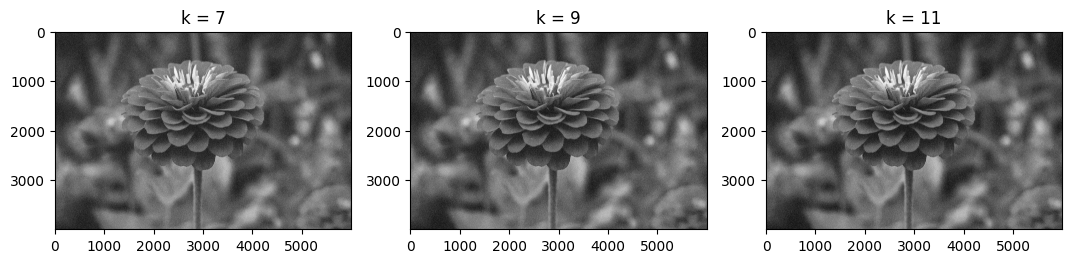

In [39]:
# Шум Гауcса
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [7, 9, 11]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.GaussianBlur(image_noise_gauss, (k, k), 0)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

k = 3: MSE = 70.30649308333334 ; SSIM = 0.6612909212736866
k = 5: MSE = 43.85617558333333 ; SSIM = 0.7099800746378444
k = 7: MSE = 30.728156666666667 ; SSIM = 0.7572436592197924


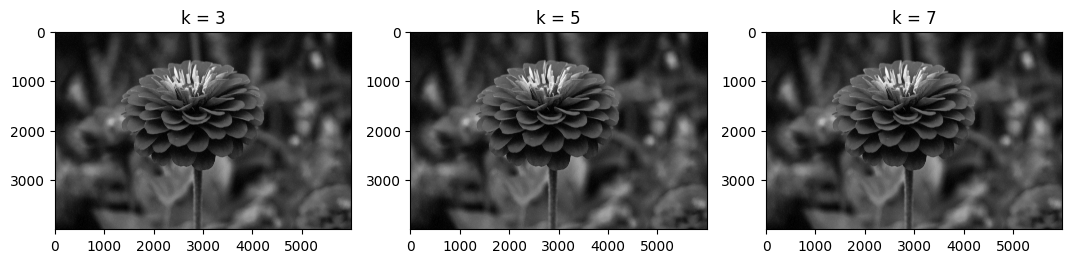

In [40]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.GaussianBlur(image_noise_sp, (k, k), 0)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

Билатериальный фильтр

k = 7: MSE = 1474.8044993333333 ; SSIM = 0.18730349489522732
k = 9: MSE = 1404.2293404583334 ; SSIM = 0.21159009621491928
k = 11: MSE = 1363.5161116666666 ; SSIM = 0.22479149765952414


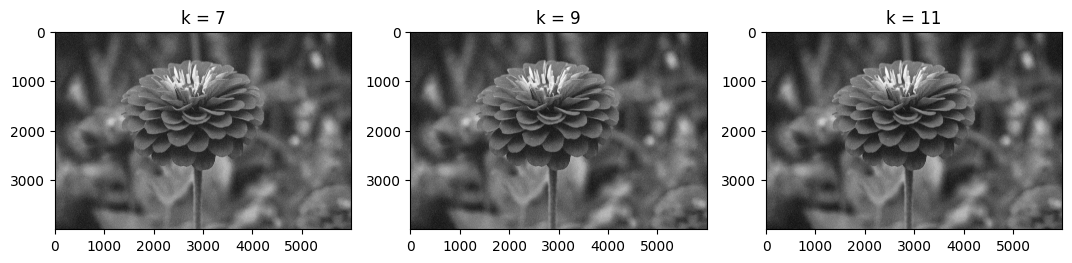

In [41]:
# Шум Гауcса
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [7, 9, 11]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.bilateralFilter(image_noise_gauss, k, 105, 105)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

k = 3: MSE = 194.09801704166668 ; SSIM = 0.6197675541431205
k = 5: MSE = 91.20025816666667 ; SSIM = 0.6568731557047491
k = 7: MSE = 47.87293275 ; SSIM = 0.7088704222930267


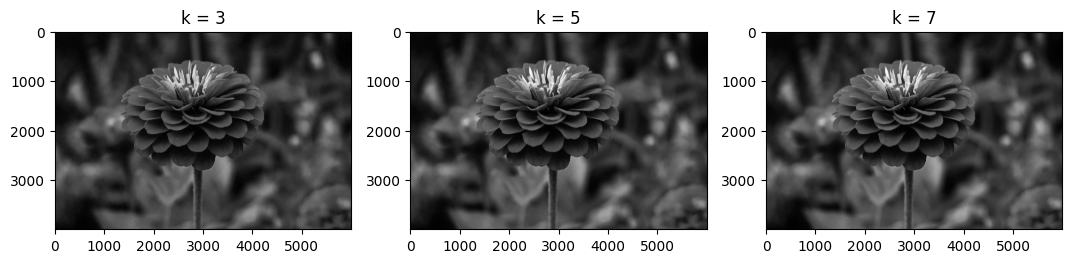

In [42]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.bilateralFilter(image_noise_sp, k, 105, 105)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

Фильтр нелокальных средних

k = 10: MSE = 4499.05329125 ; SSIM = 0.026450495051915223
k = 20: MSE = 4486.993263708333 ; SSIM = 0.029293964790394644
k = 30: MSE = 2780.705594375 ; SSIM = 0.08368444380077977


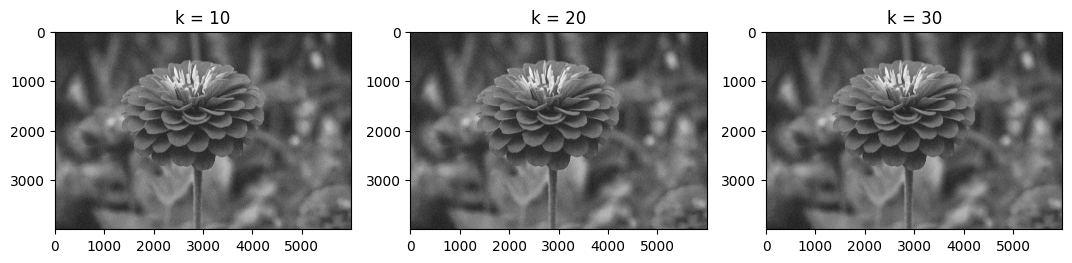

In [43]:
# Шум Гауcса
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [10, 20, 30]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.fastNlMeansDenoising(image_noise_gauss, h = k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

k = 10: MSE = 421.32753425 ; SSIM = 0.551128276548875
k = 20: MSE = 65.40193170833334 ; SSIM = 0.7442608035608882
k = 30: MSE = 16.344237333333332 ; SSIM = 0.8301811302168489


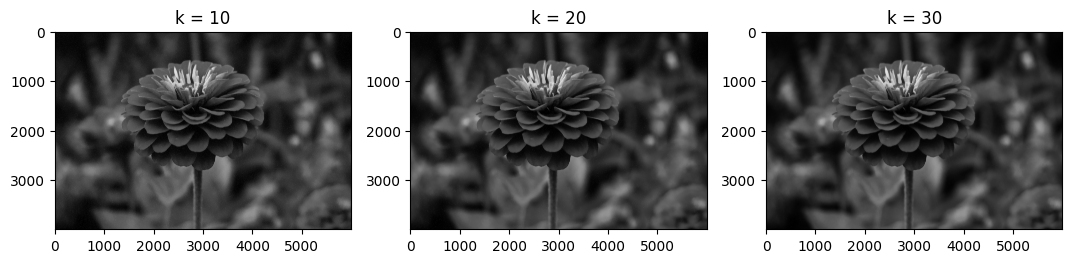

In [44]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(13, 7))

for k in [10, 20, 30]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.fastNlMeansDenoising(image_noise_sp, h = k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

# Выяснить, какой фильтр показал лучший результат фильтрации шума.

Лучший результат для шума Гауcса показал медианный фильтр

In [45]:
k = 7
res = cv2.medianBlur(image_noise_gauss, k)
mse_ssim(image_gray, res, 'k = {}'.format(k))

k = 7: MSE = 189.859616875 ; SSIM = 0.5418175196115137


Лучший результат для шума соль-перец показал медианный фильтр

In [24]:
k = 3
res = cv2.medianBlur(image_noise_sp, k)
mse_ssim(image_gray, res, 'k = {}'.format(k))

k = 3: MSE = 8.1651705 ; SSIM = 0.9069627928571827
